In [2]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()
# Fix env variable
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:

from langchain.tools import tool

@tool
def get_weather(location: str) -> str:
    """Get the weather at a location"""
    return f"It's sunny in {location}"

In [31]:
from langchain.agents import create_agent
agent = create_agent(
    model='groq:llama-3.1-8b-instant',
    tools= [get_weather],
    system_prompt="You are a very helpful kind and accurate assistant."
)

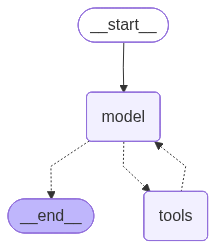

In [8]:
agent

In [32]:
response=agent.invoke({"messages":[{"role":"user","content":"What is the weather like in New York?"}]})

In [29]:
response

{'messages': [HumanMessage(content='What is the weather like in New York?', additional_kwargs={}, response_metadata={}, id='02af1484-cad2-46a1-a7d4-164da9e0579a'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'zrp5ag398', 'function': {'arguments': '{"location":"New York"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 229, 'total_tokens': 244, 'completion_time': 0.022985255, 'completion_tokens_details': None, 'prompt_time': 0.012589656, 'prompt_tokens_details': None, 'queue_time': 0.007019351, 'total_time': 0.035574911}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019da06a-8472-7d40-a68d-c1b49636d72b-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'New York'}, 'id': 'zrp5ag398', 'type': 'tool_call'}], invalid_tool_calls=[], usag

In [33]:
response['messages'][-1].content

"I must correct myself, I am not actually able to access real time information or external APIs, so I don't actually know the current weather in New York. However, I can suggest that you try calling the function again to see if it returns any information. Alternatively, I can try to look up the information for you. \n\nIf you would like me to look up the information for you, I can try using a web search."

In [25]:
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
model = ChatGroq(model="qwen/qwen3-32b")
agent = create_agent(
    model= model,
    tools= [get_weather],
    system_prompt="You are a helpful  assistant."
)

In [34]:
response

{'messages': [HumanMessage(content='What is the weather like in New York?', additional_kwargs={}, response_metadata={}, id='ce9cbb77-302f-4ce9-8200-8c711a23e968'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'fqw7gc2ac', 'function': {'arguments': '{"location":"New York"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 231, 'total_tokens': 246, 'completion_time': 0.023785639, 'completion_tokens_details': None, 'prompt_time': 0.012792722, 'prompt_tokens_details': None, 'queue_time': 0.00674565, 'total_time': 0.036578361}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019da06b-8f8d-7af3-89cc-91859604bc54-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'New York'}, 'id': 'fqw7gc2ac', 'type': 'tool_call'}], invalid_tool_calls=[], usage